# VERIFY SOURCE COVERAGE

Global `cog_worker.Manager.preview` of each staged input asset, read through the model's own acquisition path (`bii.model._read` -> `tile_index.lookup` -> `worker.read`, mosaicking the staged COGs). `preview` downsamples the ~100 m global grid to `max_size`, so this mosaics every asset's COGs at a coarse resolution — enough to eyeball whether staging produced complete global coverage with no gaps.

Reads from the default staged root (`s3://vizz-bii-processing/input_cogs`); set `config.STAGED_ROOT` to a local dir to verify a local stage instead.

In [1]:
import numpy as np
import rasterio as rio
from rasterio.plot import show
import matplotlib.pyplot as plt
import cog_worker

import os

import boto3

from bii import cog, config, model

_creds = boto3.Session().get_credentials().get_frozen_credentials()
os.environ["AWS_ACCESS_KEY_ID"] = _creds.access_key
os.environ["AWS_SECRET_ACCESS_KEY"] = _creds.secret_key
if _creds.token:
    os.environ["AWS_SESSION_TOKEN"] = _creds.token
os.environ["AWS_DEFAULT_REGION"] = "us-west-2"

year = config.START_YEAR  # annual assets (landcover/population/nightlights) previewed at this year

# Global preview grid; buffer=0 keeps edges clean, preview() caps read at max_size.
manager = cog_worker.Manager(bounds=(-180, -90, 180, 90), scale=config.SCALE_DEG, proj=config.PROJ, buffer=0)


def read_asset(worker, asset, year=None):
    return {asset: model._read(worker, asset, year)}


# Single-epoch assets at year=None, per-year assets at `year`.
assets = [(a, None) for a in model.STATIC_ASSETS] + [(a, year) for a in model.ANNUAL_ASSETS]

In [2]:
# Mosaic each asset's COGs globally at coarse res (slow: reads every tile).
with rio.Env(**cog.GDAL_READ_ENV):
    previews = {a: manager.preview(read_asset, [a, y], {}, max_size=1024)[0][a] for a, y in assets}

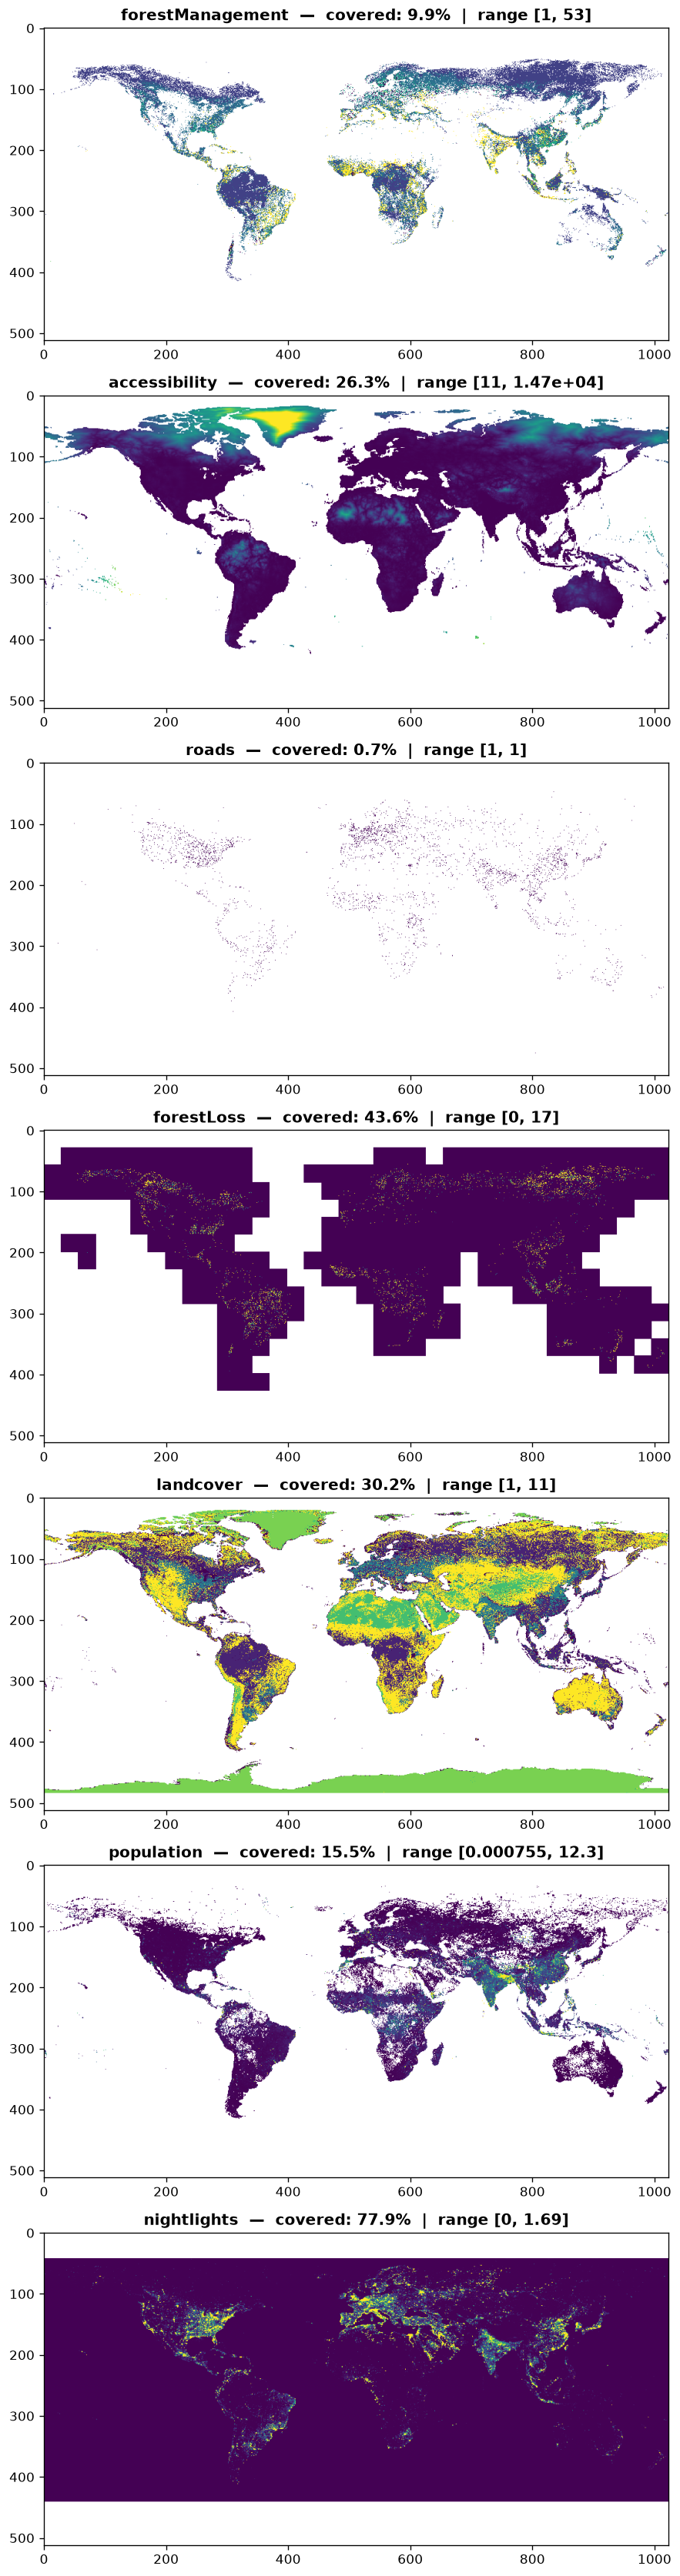

In [3]:
# 1st-99th pctile stretch; masked gaps stay blank.
fig, axes = plt.subplots(len(previews), 1, figsize=(12, 4 * len(previews)), dpi=120)
for ax, (asset, arr) in zip(axes, previews.items()):
    valid = arr.compressed() if np.ma.isMaskedArray(arr) else arr.ravel()
    covered = (~np.ma.getmaskarray(arr)).mean()
    vmin, vmax = (np.percentile(valid, [1, 99]) if valid.size else (0, 1))
    show(arr, ax=ax, cmap="viridis", vmin=vmin, vmax=vmax,
         title=f"{asset}  —  covered: {covered:.1%}  |  range [{vmin:.3g}, {vmax:.3g}]")
plt.tight_layout()